## 1. Loading Dataset

In [1]:
import os
os.environ['KAGGLE_API_TOKEN']='KGAT_123940d3279a96f42943147acd3f3c76'

In [2]:
! kaggle datasets download -d ipythonx/automated-cardiac-diagnosis

Dataset URL: https://www.kaggle.com/datasets/ipythonx/automated-cardiac-diagnosis
License(s): ODbL-1.0
100% 2.11G/2.11G [01:26<00:00, 26.3MB/s]



In [3]:
!unzip automated-cardiac-diagnosis.zip

Archive:  automated-cardiac-diagnosis.zip
  inflating: ACDC/database/LICENSE_TERMS.md  
  inflating: ACDC/database/MANDATORY_CITATION.md  
  inflating: ACDC/database/STATE-OF-THE-ART-nnUNet-method.md  
  inflating: ACDC/database/script_acdc_visu.ipynb  
  inflating: ACDC/database/testing/MANDATORY_CITATION.md  
  inflating: ACDC/database/testing/patient101/Info.cfg  
  inflating: ACDC/database/testing/patient101/MANDATORY_CITATION.md  
  inflating: ACDC/database/testing/patient101/patient101_4d.nii  
  inflating: ACDC/database/testing/patient101/patient101_frame01.nii  
  inflating: ACDC/database/testing/patient101/patient101_frame01_gt.nii  
  inflating: ACDC/database/testing/patient101/patient101_frame14.nii  
  inflating: ACDC/database/testing/patient101/patient101_frame14_gt.nii  
  inflating: ACDC/database/testing/patient102/Info.cfg  
  inflating: ACDC/database/testing/patient102/MANDATORY_CITATION.md  
  inflating: ACDC/database/testing/patient102/patient102_4d.nii  
  inflating

In [4]:
!pip install nibabel

In [5]:
!file /content/ACDC/database/training/patient001/patient001_frame01.nii

/content/ACDC/database/training/patient001/patient001_frame01.nii: directory


In [6]:
import nibabel as nib
import matplotlib.pyplot as plt

vol=nib.load('/content/ACDC/database/training/patient001/patient001_frame01.nii/CMD03Gate1.nii')
vol.shape

(216, 256, 10)

In [7]:
vol=vol.get_fdata()
vol.shape

(216, 256, 10)

In [8]:
img_0=vol[108,:,:]
img_1=vol[:,128,:]
img_2=vol[:,:,5]

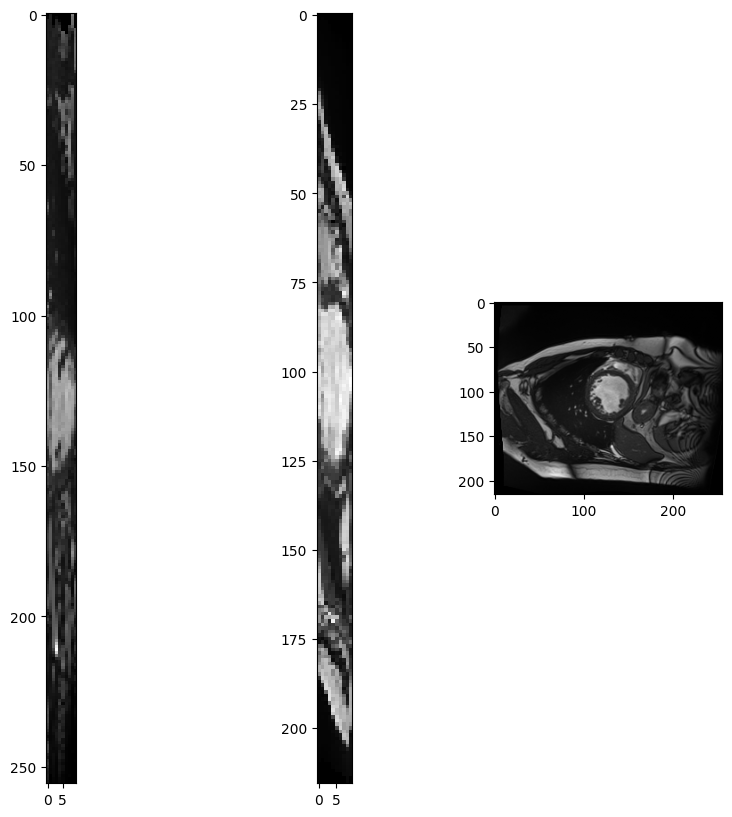

In [9]:
fig,axes=plt.subplots(1,3,figsize=(10,10))

axes[0].imshow(img_0,cmap='gray')
axes[1].imshow(img_1,cmap='gray')
axes[2].imshow(img_2,cmap='gray')

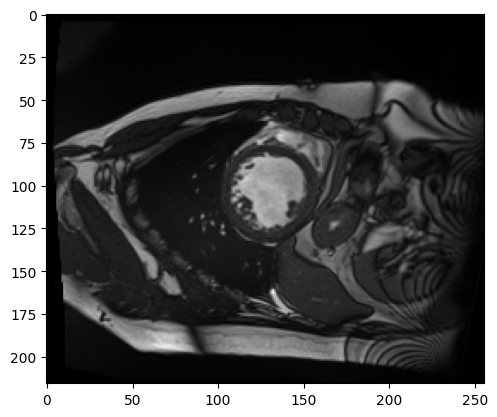

In [10]:
plt.imshow(img_2,cmap='gray')

In [11]:
vol_gt=nib.load('/content/ACDC/database/training/patient001/patient001_frame01_gt.nii/DCM03-OH-AL_V2_1.nii')
vol_gt=vol_gt.get_fdata()
vol_gt.shape

(216, 256, 10)

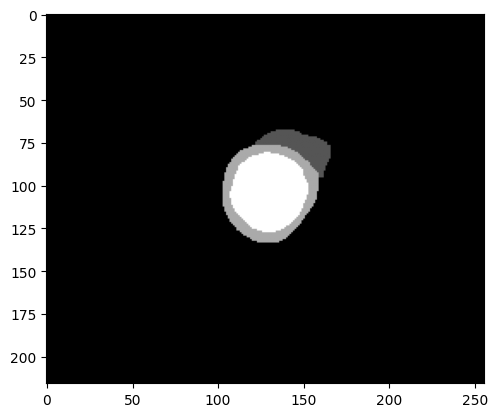

In [12]:
plt.imshow(vol_gt[:,:,5],cmap='gray')

In [13]:
import numpy as np

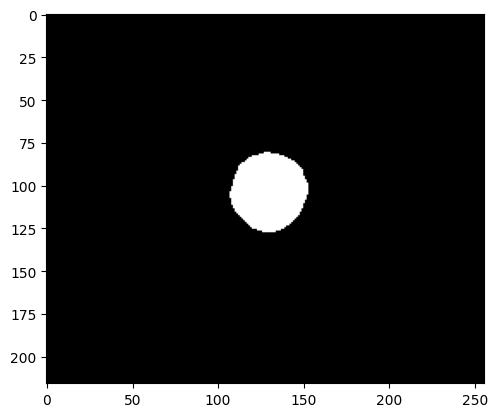

In [14]:
mask=(vol_gt[:,:,5]==3).astype(np.int32)
plt.imshow(mask, cmap='gray')

In [15]:
def data_extraction(dir,count):
  patients=[]

  for patient in sorted(os.listdir(dir)):

    patient_path=os.path.join(dir,patient)

    data={
        'patient':patient,
        'mask':{},
        'image':{}
    }

    if (not os.path.isdir(patient_path)):
      continue

    for item in sorted(os.listdir(patient_path)):

      if '4d' in item:
          continue

      item_path=os.path.join(patient_path,item)

      if(os.path.isdir(item_path)):

        nii_files=[f for f in os.listdir(item_path) if f.endswith('.nii')] # all the nii files in the diectories per partient

        nii_path=os.path.join(item_path,nii_files[0])

        frame=item.split('_')[1]

        # so patient001_frame01.nii -> ['patient001','_frame01.nii'], for img and patient001_frame12_gt.nii -> ['patient001','_frame12','_gt.nii'] for mask.

        frame=frame.replace('.nii','') # to equalize it all


        if '_gt' in item:
          data['mask'][frame]=nii_path
        else:
          data['image'][frame]=nii_path

    patients.append(data)
    count+=1

  return patients,count

In [61]:
def data_extraction_test(dir,count):
  patients=[]

  for patient in sorted(os.listdir(dir)):

    patient_path=os.path.join(dir,patient)

    data={
        'patient':patient,
        'mask':{},
        'image':{}
    }

    if (not os.path.isdir(patient_path)):
      continue

    for item in sorted(os.listdir(patient_path)):

      if '4d' in item:
          continue

      if not item.endswith('.nii'):
        continue

      item_path=os.path.join(patient_path,item)

      frame=item.split('_')[1]

        # so patient001_frame01.nii -> ['patient001','_frame01.nii'], for img and patient001_frame12_gt.nii -> ['patient001','_frame12','_gt.nii'] for mask.

      if '_gt' in item:

        frame=frame.replace('_gt.nii','') # to equalize it all
        data['mask'][frame]=item_path

      else:
        frame=frame.replace('.nii','') # to equalize it all
        data['image'][frame]=item_path

    patients.append(data)
    count+=1

  return patients,count

In [62]:
patients,count=data_extraction('/content/ACDC/database/training',0)
count

100

In [63]:
patients[0]['mask'], patients[0], patients[0]['image']

({'frame01': '/content/ACDC/database/training/patient001/patient001_frame01_gt.nii/DCM03-OH-AL_V2_1.nii',
  'frame12': '/content/ACDC/database/training/patient001/patient001_frame12_gt.nii/DCM03-OH-AL_V2_12.nii'},
 {'patient': 'patient001',
  'mask': {'frame01': '/content/ACDC/database/training/patient001/patient001_frame01_gt.nii/DCM03-OH-AL_V2_1.nii',
   'frame12': '/content/ACDC/database/training/patient001/patient001_frame12_gt.nii/DCM03-OH-AL_V2_12.nii'},
  'image': {'frame01': '/content/ACDC/database/training/patient001/patient001_frame01.nii/CMD03Gate1.nii',
   'frame12': '/content/ACDC/database/training/patient001/patient001_frame12.nii/CMD03Gate12.nii'}},
 {'frame01': '/content/ACDC/database/training/patient001/patient001_frame01.nii/CMD03Gate1.nii',
  'frame12': '/content/ACDC/database/training/patient001/patient001_frame12.nii/CMD03Gate12.nii'})

In [64]:
img_frame_1=nib.load('/content/ACDC/database/training/patient001/patient001_frame01.nii/CMD03Gate1.nii').get_fdata()[:,:,5]
mask_frame_1=nib.load('/content/ACDC/database/training/patient001/patient001_frame01_gt.nii/DCM03-OH-AL_V2_1.nii').get_fdata()[:,:,5]
img_frame_12=nib.load('/content/ACDC/database/training/patient001/patient001_frame12.nii/CMD03Gate12.nii').get_fdata()[:,:,5]
mask_frame_12=nib.load('/content/ACDC/database/training/patient001/patient001_frame12_gt.nii/DCM03-OH-AL_V2_12.nii').get_fdata()[:,:,5]

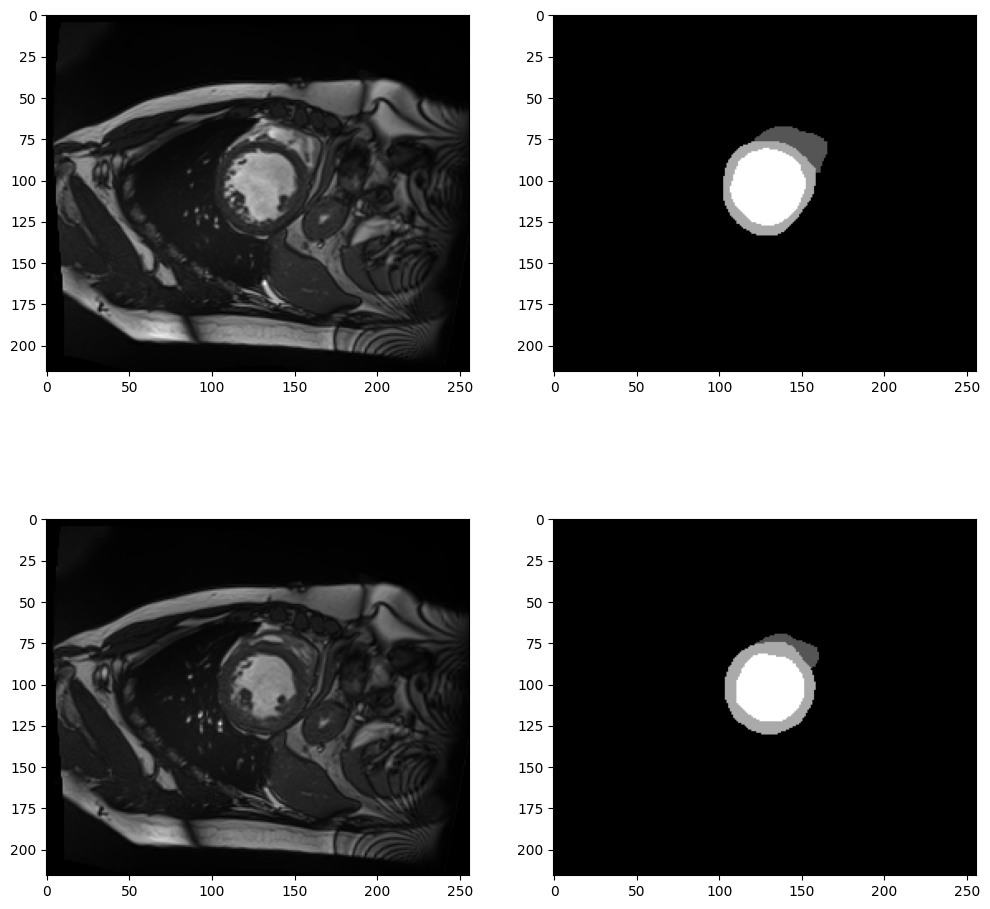

In [65]:
import imageio.v2 as imageio

fig,axes=plt.subplots(2,2,figsize=(12,12))
axes[0][0].imshow(img_frame_1,cmap='gray')
axes[0][1].imshow(mask_frame_1,cmap='gray')
axes[1][0].imshow(img_frame_12,cmap='gray')
axes[1][1].imshow(mask_frame_12,cmap='gray')

In [66]:
mask_frame_1.shape,mask_frame_12.shape

((216, 256), (216, 256))

In [67]:
mask_frame_1=np.array([mask_frame_1==3]).astype(np.int32)
mask_frame_12=np.array([mask_frame_12==3]).astype(np.int32)
mask_frame_1.shape,mask_frame_12.shape

((1, 216, 256), (1, 216, 256))

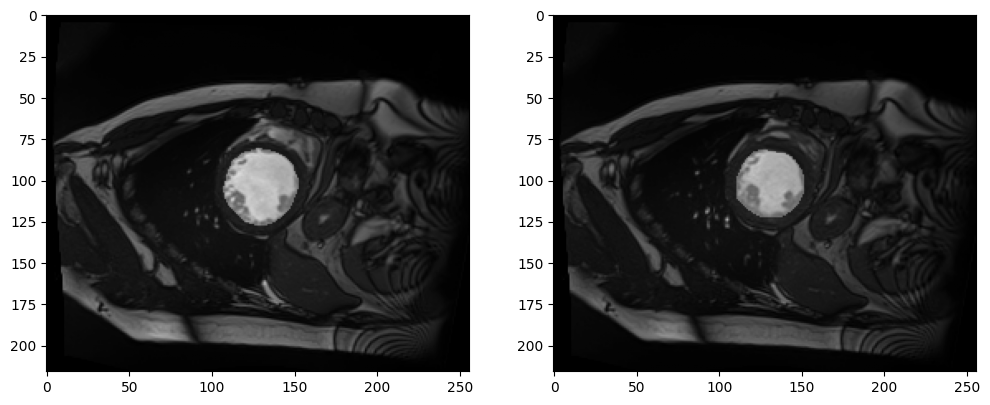

In [69]:
import imageio.v2 as imageio

fig,axes=plt.subplots(1,2,figsize=(12,12))
axes[0].imshow(img_frame_1,cmap='gray')
axes[0].imshow(mask_frame_1.squeeze(), cmap='gray', alpha=0.3)
axes[1].imshow(img_frame_12,cmap='gray')
axes[1].imshow(mask_frame_12.squeeze(), cmap='gray', alpha=0.3)

(np.float64(-0.5), np.float64(255.5), np.float64(215.5), np.float64(-0.5))

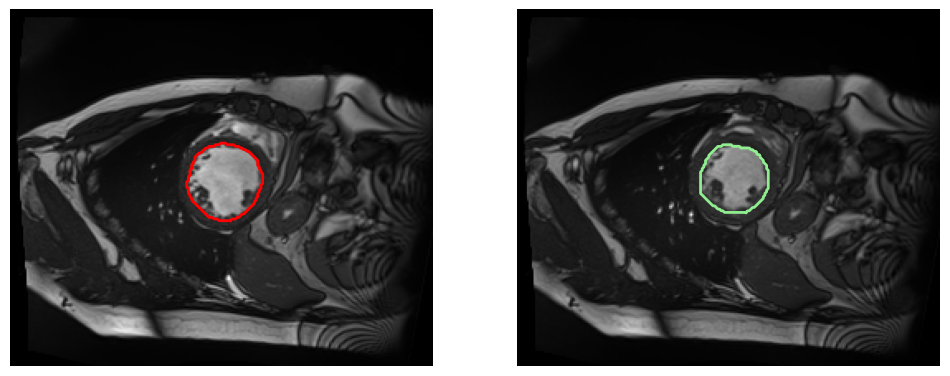

In [70]:
from skimage.measure import find_contours

fig,axes=plt.subplots(1,2,figsize=(12,12))

for coords in find_contours(mask_frame_1.squeeze(),0.5):
  axes[0].plot(coords[:,1],coords[:,0], color='red', linewidth=2)

for coords in find_contours(mask_frame_12.squeeze(),0.5):
  axes[1].plot(coords[:,1],coords[:,0], color='lightgreen', linewidth=2)

axes[0].imshow(img_frame_1,cmap='gray')
axes[1].imshow(img_frame_12,cmap='gray')

axes[0].axis(False)
axes[1].axis(False)

## 2. Test DataLoading

In [71]:
patients_test,count=data_extraction_test('/content/ACDC/database/testing',0)
count

50

In [73]:
patients_test[0]

{'patient': 'patient101',
 'mask': {'frame01': '/content/ACDC/database/testing/patient101/patient101_frame01_gt.nii',
  'frame14': '/content/ACDC/database/testing/patient101/patient101_frame14_gt.nii'},
 'image': {'frame01': '/content/ACDC/database/testing/patient101/patient101_frame01.nii',
  'frame14': '/content/ACDC/database/testing/patient101/patient101_frame14.nii'}}

In [74]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional, InterpolationMode
import torch
import random

class ACDC_Dataset(Dataset):

  def __init__(self,patients,transform=True):
    self.patients=[]
    self.transforms=transform

    for patient in patients:

      patient_id=patient['patient']

      for frame in patient['image']:

        img_path=patient['image'][frame]
        mask_path=patient['mask'][frame]

        img_load=nib.load(img_path).get_fdata()
        mask_load=nib.load(mask_path).get_fdata()

        # mid=img_load.shape[2]//2

        # img_load=img_load[:,:,mid]
        # mask_load=mask_load[:,:,mid]

        mask_load=(mask_load==3).astype(np.float32)

        for i in range(img_load.shape[2]):

          self.patients.append({
              'patient_id':patient_id,
              'frame':frame,
              'slice':i,
              'img':img_load[:,:,i],
              'mask':mask_load[:,:,i],
          })

  def __len__(self):
    return len(self.patients)


  def __getitem__(self,idx):


    img=self.patients[idx]['img']
    mask=self.patients[idx]['mask']

    img=torch.tensor(img).float().unsqueeze(0)  # channel dimension from unsqueeze
    mask=torch.tensor(mask).float().unsqueeze(0)

    # if self.transforms:

    c,h,w=img.shape
    # First pad it to wa square and then resize it.
    max_dim=max(h,w)
    padding_h=max_dim-h
    padding_w=max_dim-w

    top_h=padding_h//2
    left_w=padding_w//2

    bottom_h=padding_h-top_h
    right_w=padding_w-left_w

    img=functional.pad(img,(left_w,right_w,top_h,bottom_h))
    mask=functional.pad(mask,(left_w,right_w,top_h,bottom_h))

    img=functional.resize(img,(256,256),interpolation=InterpolationMode.BILINEAR)
    mask=functional.resize(mask,(256,256),interpolation=InterpolationMode.NEAREST)

  #     if random.random()>0.5:
  #       img=functional.hflip(img)
  #       mask=functional.hflip(mask)

  #     # if random.random()>0.5:
  #     #   img=functional.vflip(img)
  #     #   mask=functional.vflip(mask)

  #     # theta=random.randint(-10,10)

  #     # img=functional.rotate(img,theta, interpolation=InterpolationMode.BILINEAR)
  #     # mask=functional.rotate(mask,theta, interpolation=InterpolationMode.NEAREST)

      # img=functional.normalize(img, mean=[0.5],std=[0.5])

    return img,mask,self.patients[idx]['patient_id'],self.patients[idx]['frame'],self.patients[idx]['slice']

In [75]:
train_dataset=ACDC_Dataset(patients, transform=True)
test_dataset=ACDC_Dataset(patients_test, transform=False)

In [88]:
train_dataloader=DataLoader(train_dataset, batch_size=8, shuffle=True)
test_dataloader=DataLoader(test_dataset, batch_size=1, shuffle=False)

In [78]:
img,mask,id,frame,s=next(iter(train_dataloader))
img[0].shape,mask[0].shape

(torch.Size([1, 256, 256]), torch.Size([1, 256, 256]))

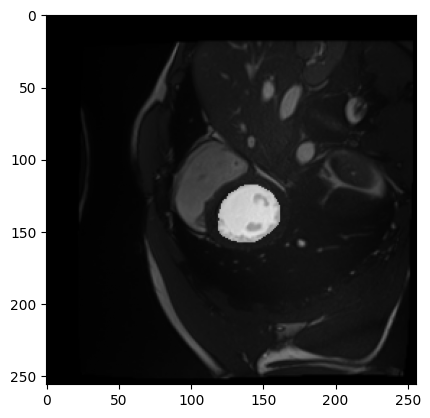

In [79]:
plt.imshow(img[1].squeeze(), cmap='gray')
plt.imshow(mask[1].squeeze(), cmap='gray', alpha=0.5)

## 3. Model Definition

In [80]:
!pip install segmentation_models_pytorch

In [40]:
from segmentation_models_pytorch import Unet

model=Unet(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=1,
    classes=1
) # in_channels is colour channels

In [41]:
model.state_dict, model.parameters()

(<bound method Module.state_dict of Unet(
   (encoder): ResNetEncoder(
     (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
     (layer1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu): ReLU(inplace=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
       )
       (1): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNo

In [42]:
device='cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [43]:
model.to(device)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [44]:
import segmentation_models_pytorch
import torch.nn as nn

bce_loss=nn.BCEWithLogitsLoss()
dice_loss=segmentation_models_pytorch.losses.DiceLoss(
    from_logits=True,
    mode='binary'
)

In [45]:
def criterion(pred,target):
  return dice_loss(pred,target)+bce_loss(pred,target)

In [46]:
optimizer=torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)

In [47]:
epochs=10

for epoch in range(epochs):

  model.train()
  train_loss=0

  for img,mask,_,_,_ in train_dataloader:

    img=img.to(device)
    mask=mask.to(device)

    optimizer.zero_grad()

    pred=model(img)

    loss=criterion(pred,mask)

    loss.backward()
    optimizer.step()

    train_loss+=loss.item()

  print(f"{epoch+1}: Train Loss: {train_loss/len(train_dataloader)}")


1: Train Loss: 0.42026601750488696
2: Train Loss: 0.13322048093358133
3: Train Loss: 0.08522639741704344
4: Train Loss: 0.08913852097509115
5: Train Loss: 0.08825366546029914
6: Train Loss: 0.08156611574771197
7: Train Loss: 0.08601522330007597
8: Train Loss: 0.07109907880153286
9: Train Loss: 0.07966629635185411
10: Train Loss: 0.07598085124811081


In [96]:
model.eval()

test_loss=0
preds=[]
with torch.inference_mode():

  for img,mask,patient,frame,idx in test_dataloader:

    img=img.to(device)
    mask=mask.to(device)

    pred=model(img)

    loss=criterion(pred,mask)
    test_loss+=loss.item()

    pred=torch.sigmoid(pred)

    pred=(pred>0.5).float()


    preds.append({'patient':patient[0],
                 'frame':frame[0],
                 'slice':idx.item(),
                 'mask':pred[0,0].cpu().numpy() # pred has batch,c,h,w, so it returns [h,w]
                 })

print(f"Test Loss: {test_loss/len(test_dataloader)}")

Test Loss: 0.23063831456593073


In [97]:
# Now, u need to grp ['patient', 'frame'] to make the keys

In [103]:
from collections import defaultdict

grouped=defaultdict(list) # creates list for missing keys

for pred in preds:
  grouped[(pred['patient'],pred['frame'])].append(pred)

In [106]:
#now, the slices need to be places inproper order, so in order of sorted idx
for key in grouped:
  grouped[key]=sorted(grouped[key], key=lambda x:x['slice'])

In [108]:
vols={}

for key in grouped:

  patient,frame=key

  for p in patients_test:
    if p['patient']==patient:
      img_path=p['image'][frame]
      break

  img_load=nib.load(img_path)
  x_scale,y_scale,z_scale=img_load.header.get_zooms()[:3]

  total_vol=0

  for sliced_data in grouped[key]:
    pixels=np.sum(sliced_data['mask'])
    total_vol+=(pixels*x_scale*y_scale*z_scale)

  vols[key]=total_vol/1000

In [124]:
patient_ef={}

patients=set(patient for patient,frame in vols.keys())

for patient in patients:

  frame_vols=[]
  for (p,f),volume in vols.items():

    if p==patient:
      frame_vols.append(volume)

  edv=max(frame_vols)
  esv=min(frame_vols)

  ef=((edv-esv)/edv)*100

  patient_ef[patient]={
      'EDV':edv,
      'ESV':esv,
      'EF':ef
  }

In [125]:
patient_ef

{'patient141': {'EDV': np.float32(122.63877),
  'ESV': np.float32(39.72068),
  'EF': np.float32(67.61165)},
 'patient108': {'EDV': np.float32(164.16016),
  'ESV': np.float32(26.831055),
  'EF': np.float32(83.65556)},
 'patient136': {'EDV': np.float32(267.73685),
  'ESV': np.float32(165.93922),
  'EF': np.float32(38.021523)},
 'patient111': {'EDV': np.float32(83.23462),
  'ESV': np.float32(23.058105),
  'EF': np.float32(72.29746)},
 'patient124': {'EDV': np.float32(183.73251),
  'ESV': np.float32(61.173386),
  'EF': np.float32(66.70519)},
 'patient140': {'EDV': np.float32(194.59111),
  'ESV': np.float32(95.97186),
  'EF': np.float32(50.680244)},
 'patient115': {'EDV': np.float32(168.6026),
  'ESV': np.float32(103.572845),
  'EF': np.float32(38.56984)},
 'patient145': {'EDV': np.float32(220.12419),
  'ESV': np.float32(178.37968),
  'EF': np.float32(18.96407)},
 'patient106': {'EDV': np.float32(260.83987),
  'ESV': np.float32(244.23828),
  'EF': np.float32(6.3646684)},
 'patient131': {'ED

In [126]:
true_vols={}

for p in patients_test:

  patient_id=p['patient']

  for frame in p['mask']:

    mask_path=p['mask'][frame]
    img_path=p['image'][frame]

    mask_load=nib.load(mask_path).get_fdata()
    mask=(mask_load==3).astype(np.float32)

    img_load=nib.load(img_path)
    x_scale,y_scale,z_scale=img_load.header.get_zooms()[:3]
    total_vol=0

    for i in range(mask.shape[2]):

      pixels=np.sum(mask[:,:,i])
      total_vol+=(pixels*x_scale*y_scale*z_scale)

    true_vols[(patient_id,frame)]=total_vol/1000

In [127]:
true_patient_ef={}

patients=set(patient for patient,frame in true_vols.keys())

for patient in patients:

  frame_vols=[]
  for (p,f),volume in true_vols.items():

    if p==patient:
      frame_vols.append(volume)

  edv=max(frame_vols)
  esv=min(frame_vols)

  ef=((edv-esv)/edv)*100

  true_patient_ef[patient]={
      'EDV':edv,
      'ESV':esv,
      'EF':ef
  }

In [128]:
patient_ef

{'patient141': {'EDV': np.float32(122.63877),
  'ESV': np.float32(39.72068),
  'EF': np.float32(67.61165)},
 'patient108': {'EDV': np.float32(164.16016),
  'ESV': np.float32(26.831055),
  'EF': np.float32(83.65556)},
 'patient136': {'EDV': np.float32(267.73685),
  'ESV': np.float32(165.93922),
  'EF': np.float32(38.021523)},
 'patient111': {'EDV': np.float32(83.23462),
  'ESV': np.float32(23.058105),
  'EF': np.float32(72.29746)},
 'patient124': {'EDV': np.float32(183.73251),
  'ESV': np.float32(61.173386),
  'EF': np.float32(66.70519)},
 'patient140': {'EDV': np.float32(194.59111),
  'ESV': np.float32(95.97186),
  'EF': np.float32(50.680244)},
 'patient115': {'EDV': np.float32(168.6026),
  'ESV': np.float32(103.572845),
  'EF': np.float32(38.56984)},
 'patient145': {'EDV': np.float32(220.12419),
  'ESV': np.float32(178.37968),
  'EF': np.float32(18.96407)},
 'patient106': {'EDV': np.float32(260.83987),
  'ESV': np.float32(244.23828),
  'EF': np.float32(6.3646684)},
 'patient131': {'ED

In [138]:
pred_vals=[]
true_vals=[]

for patient in sorted(patient_ef.keys()):
  pred=patient_ef[patient]
  true=true_patient_ef[patient]

  pred_vals.append(pred)
  true_vals.append(true)

  error=abs(pred['EDV']-true['EDV'])
  acc=(1-error/true['EDV'])*100

  print(f"{patient}, Accuracy: {acc}%")

patient101, Accuracy: 77.70252990722656%
patient102, Accuracy: 84.26551818847656%
patient103, Accuracy: 96.80732727050781%
patient104, Accuracy: 97.28197479248047%
patient105, Accuracy: 90.75497436523438%
patient106, Accuracy: 91.75543212890625%
patient107, Accuracy: 91.61272430419922%
patient108, Accuracy: 97.53408813476562%
patient109, Accuracy: 76.71021270751953%
patient110, Accuracy: 86.98696899414062%
patient111, Accuracy: 90.39948272705078%
patient112, Accuracy: 93.11532592773438%
patient113, Accuracy: 53.860252380371094%
patient114, Accuracy: 34.50602722167969%
patient115, Accuracy: 90.93657684326172%
patient116, Accuracy: 96.04159545898438%
patient117, Accuracy: 65.10316467285156%
patient118, Accuracy: 99.5133285522461%
patient119, Accuracy: 74.08515167236328%
patient120, Accuracy: 99.18219757080078%
patient121, Accuracy: 91.69020080566406%
patient122, Accuracy: 95.06380462646484%
patient123, Accuracy: 86.34679412841797%
patient124, Accuracy: 49.12809753417969%
patient125, Accu

In [141]:
pred_ef=[i['EF'] for i in pred_vals]
true_ef=[i['EF'] for i in true_vals]

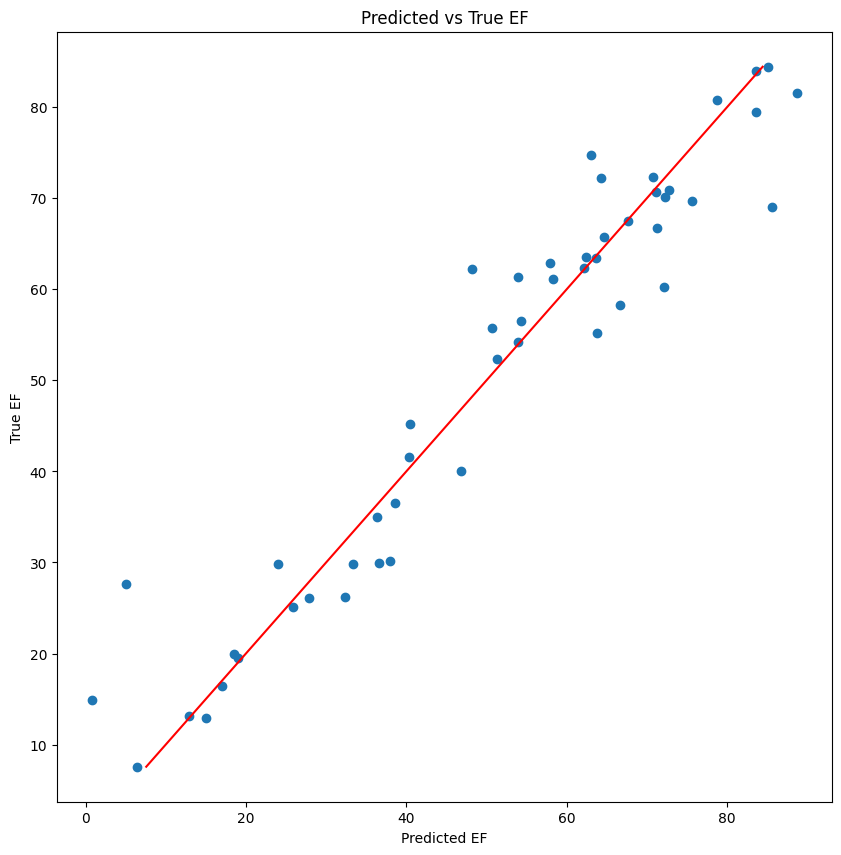

In [142]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.scatter(pred_ef,true_ef)

plt.plot(
    [min(true_ef),max(true_ef)],
    [min(true_ef),max(true_ef)],
    color='red',
)

plt.xlabel('Predicted EF')
plt.ylabel('True EF')
plt.title('Predicted vs True EF')

plt.show()

In [143]:
torch.save(model.state_dict(),'ef_model.pth')

In [144]:
from google.colab import files
files.download('ef_model.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>